# GapJumpTrial Environment Demo

Demonstrates the discrete-trial gap-jumping environment (Liska et al. eLife paradigm):
1. Arena rendering — take-off platform, gap, landing platform
2. Zero-action rollout with **trial phase timeline** (HOLD → DECISION → JUMP)
3. Video from `close_profile-rodent` camera
4. Multi-gap distance comparison
5. Reward breakdown (sparse vs dense)

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
import jax
import jax.numpy as jp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mediapy as media
import mujoco
import numpy as np
from tqdm import tqdm

from vnl_playground.tasks.rodent.gap_jump_trial import (
    GapJumpTrial,
    default_config,
    dense_config,
    PHASE_HOLD,
    PHASE_DECISION,
    PHASE_JUMP,
    OUTCOME_ONGOING,
    OUTCOME_SUCCESS,
    OUTCOME_FAILURE,
    OUTCOME_ABORT,
    OUTCOME_TIMEOUT,
)

## 1. Initialize Environment and Render Arena

In [3]:
cfg = default_config()
env = GapJumpTrial(config=cfg)
mj_model = env.mj_model
fps = int(1.0 / env.dt)

print(f"Action size: {env.action_size}")
print(f"Obs size: {env.observation_size}")
print(f"FPS: {fps}")
print(f"Gap distances (m): {list(cfg.gap_distances)}")
print(f"Hold duration: {cfg.hold_duration} steps")
print(f"Takeoff platform length: {cfg.takeoff_platform_length}m")
print(f"Cameras: {[mj_model.camera(i).name for i in range(mj_model.ncam)]}")

Warp 1.12.0.dev20260222 initialized:
   Git commit: 46b17734a17b4663afc59b06f456f22fed81f23f
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.12.0.dev20260222
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Action size: 38
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 12773d5 load on device 'cuda:0' took 6.86 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 0.28 ms  (cached)
Module _nxn_broadphase__locals__kernel_ad5e5280 ad5e528 load on device 'cuda:0' took 0.34 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_20ba1e98 20ba1e9 load on device 'cuda:0' took 1.00 ms  (cached)
Module c

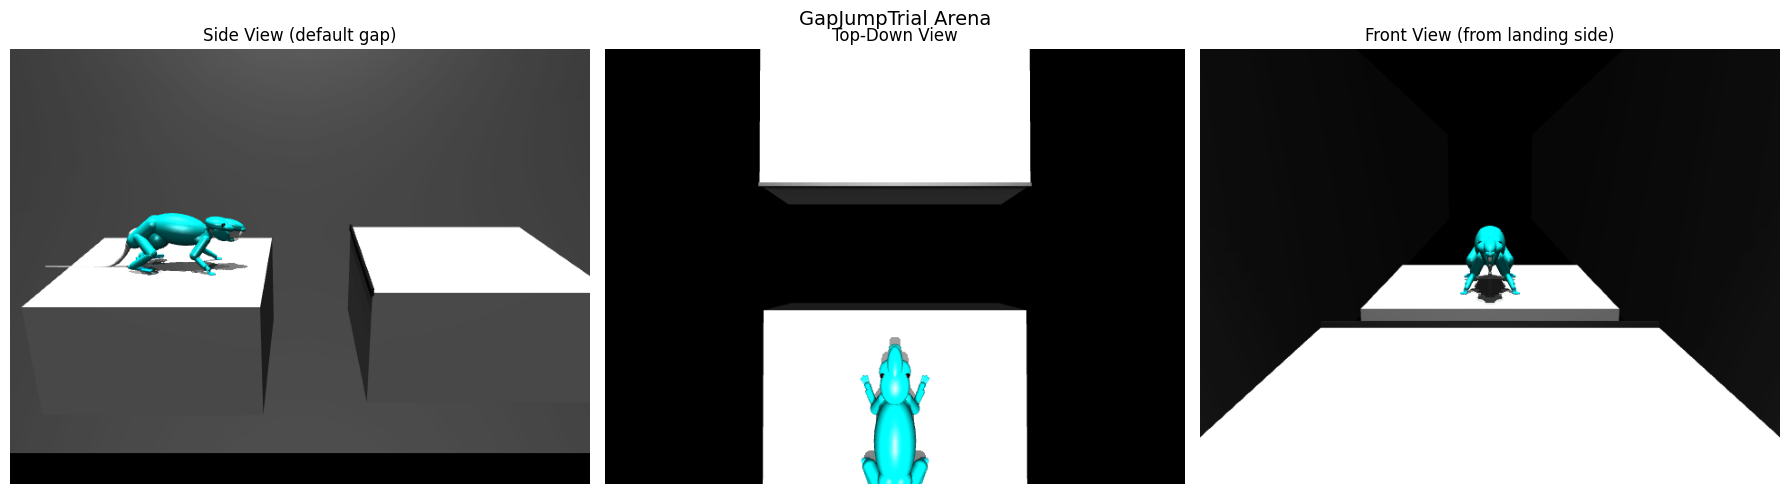

In [4]:
# Render static views of the arena
mj_data = mujoco.MjData(mj_model)
mujoco.mj_forward(mj_model, mj_data)

renderer = mujoco.Renderer(mj_model, height=480, width=640)

cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE

# Side view showing both platforms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# View 1: Side view
cam.distance = 0.8
cam.elevation = -20
cam.azimuth = 90
cam.lookat[:] = [0.2, 0.0, 0.0]
renderer.update_scene(mj_data, camera=cam)
axes[0].imshow(renderer.render())
axes[0].set_title("Side View (default gap)")
axes[0].axis("off")

# View 2: Top-down view
cam.distance = 0.6
cam.elevation = -89
cam.azimuth = 0
cam.lookat[:] = [0.2, 0.0, 0.0]
renderer.update_scene(mj_data, camera=cam)
axes[1].imshow(renderer.render())
axes[1].set_title("Top-Down View")
axes[1].axis("off")

# View 3: Front view (from landing side)
cam.distance = 0.6
cam.elevation = -10
cam.azimuth = 180
cam.lookat[:] = [0.15, 0.0, 0.05]
renderer.update_scene(mj_data, camera=cam)
axes[2].imshow(renderer.render())
axes[2].set_title("Front View (from landing side)")
axes[2].axis("off")

plt.suptitle("GapJumpTrial Arena", fontsize=14)
plt.tight_layout()
plt.show()

renderer.close()

### Multiple Gap Distances Side-by-Side

Show the arena configured at each of the 5 gap distances.

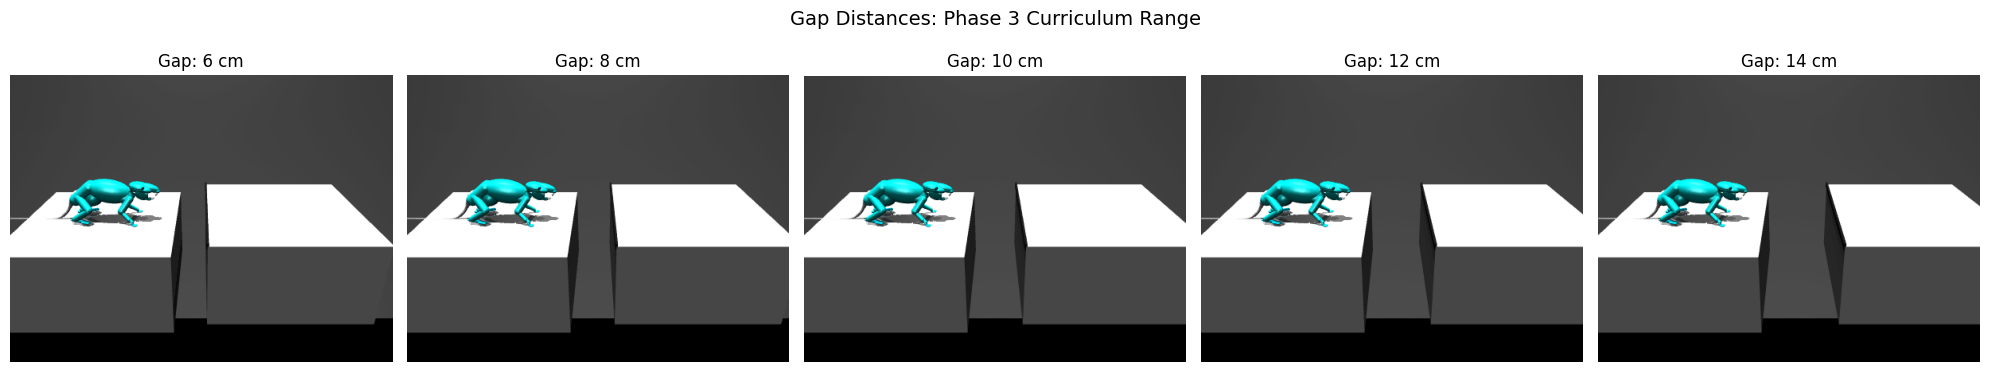

In [5]:
gap_distances_to_show = [0.06, 0.08, 0.10, 0.12, 0.14]

fig, axes = plt.subplots(
    1, len(gap_distances_to_show), figsize=(4 * len(gap_distances_to_show), 4)
)

for ax, gap_d in zip(axes, gap_distances_to_show):
    gap_cfg = default_config()
    gap_cfg.gap_distances = (gap_d,)
    gap_env = GapJumpTrial(config=gap_cfg)
    gap_mj_model = gap_env.mj_model
    gap_mj_data = mujoco.MjData(gap_mj_model)
    mujoco.mj_forward(gap_mj_model, gap_mj_data)

    gap_renderer = mujoco.Renderer(gap_mj_model, height=360, width=480)
    cam = mujoco.MjvCamera()
    cam.type = mujoco.mjtCamera.mjCAMERA_FREE
    cam.distance = 0.7
    cam.elevation = -25
    cam.azimuth = 90
    cam.lookat[:] = [0.2, 0.0, 0.0]
    gap_renderer.update_scene(gap_mj_data, camera=cam)
    ax.imshow(gap_renderer.render())
    ax.set_title(f"Gap: {gap_d*100:.0f} cm")
    ax.axis("off")
    gap_renderer.close()

plt.suptitle("Gap Distances: Phase 3 Curriculum Range", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Zero-Action Rollout with Trial Phase Timeline

Run the environment with zero actions to observe:
- Phase transitions: HOLD (blue) → DECISION (yellow) → JUMP (red)
- Torso position relative to gap edges
- Reward signals over time

In [6]:
env = GapJumpTrial(config=default_config())
rng = jax.random.PRNGKey(0)
state = jax.jit(env.reset)(rng)
step_fn = jax.jit(env.step)

n_steps = 300
qposes = [np.array(state.data.qpos)]
rewards = []
phases = []
outcomes = []
torso_xs = []
torso_zs = []
gap_dist = float(state.info["gap_distance"])

print(f"Sampled gap distance: {gap_dist*100:.1f} cm")

for i in tqdm(range(n_steps), desc="Zero-action rollout"):
    action = jp.zeros(env.action_size)
    state = step_fn(state, action)
    qposes.append(np.array(state.data.qpos))
    rewards.append(float(state.reward))
    phases.append(int(state.info["trial_phase"]))
    outcomes.append(int(state.info["trial_outcome"]))

    torso = state.data.bind(env.mjx_model, env._spec.body("torso-rodent"))
    torso_xs.append(float(torso.xpos[0]))
    torso_zs.append(float(torso.xpos[2]))

    if state.done > 0.5:
        print(f"Episode terminated at step {i+1}, outcome: {outcomes[-1]}")
        break

qposes = np.array(qposes)
rewards = np.array(rewards)
phases = np.array(phases)
outcomes = np.array(outcomes)
torso_xs = np.array(torso_xs)
torso_zs = np.array(torso_zs)

print(f"Total steps: {len(rewards)}")
print(f"Mean reward: {rewards.mean():.4f}")
print(
    f"Final outcome: {outcomes[-1]} (0=ongoing, 1=success, 2=failure, 3=abort, 4=timeout)"
)

Sampled gap distance: 10.0 cm


Zero-action rollout: 100%|██████████| 300/300 [00:11<00:00, 26.99it/s]

Total steps: 300
Mean reward: 0.0288
Final outcome: 0 (0=ongoing, 1=success, 2=failure, 3=abort, 4=timeout)


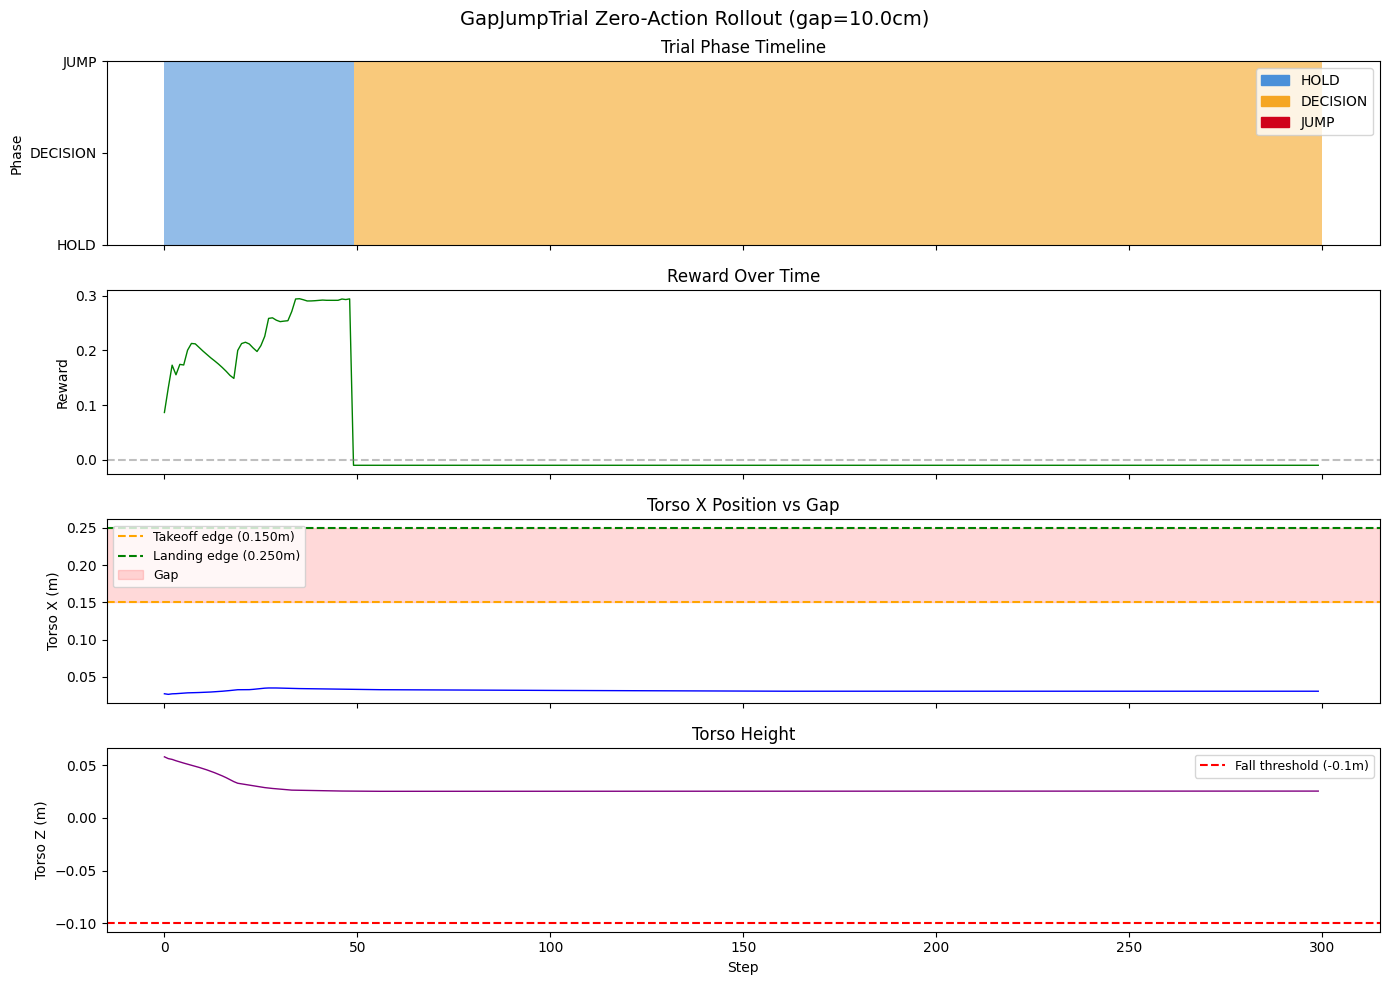

In [7]:
# Phase colors
phase_colors = {PHASE_HOLD: "#4A90D9", PHASE_DECISION: "#F5A623", PHASE_JUMP: "#D0021B"}
phase_names = {PHASE_HOLD: "HOLD", PHASE_DECISION: "DECISION", PHASE_JUMP: "JUMP"}

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

steps = np.arange(len(rewards))

# ---- Panel 1: Phase timeline as colored bands ----
ax = axes[0]
for i, phase_val in enumerate(phases):
    ax.axvspan(
        i, i + 1, alpha=0.6, color=phase_colors.get(phase_val, "gray"), linewidth=0
    )
ax.set_ylabel("Phase")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["HOLD", "DECISION", "JUMP"])
ax.set_title("Trial Phase Timeline")
legend_patches = [
    mpatches.Patch(color=c, label=phase_names[p]) for p, c in phase_colors.items()
]
ax.legend(handles=legend_patches, loc="upper right")

# ---- Panel 2: Reward over time ----
ax = axes[1]
ax.plot(steps, rewards, color="green", linewidth=1)
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.set_ylabel("Reward")
ax.set_title("Reward Over Time")

# ---- Panel 3: Torso X position with gap markers ----
ax = axes[2]
takeoff_edge = env._takeoff_trailing_edge_x
landing_edge = takeoff_edge + gap_dist
ax.plot(steps, torso_xs, color="blue", linewidth=1)
ax.axhline(
    y=takeoff_edge,
    color="orange",
    linestyle="--",
    label=f"Takeoff edge ({takeoff_edge:.3f}m)",
)
ax.axhline(
    y=landing_edge,
    color="green",
    linestyle="--",
    label=f"Landing edge ({landing_edge:.3f}m)",
)
ax.axhspan(takeoff_edge, landing_edge, alpha=0.15, color="red", label="Gap")
ax.set_ylabel("Torso X (m)")
ax.set_title("Torso X Position vs Gap")
ax.legend(loc="upper left", fontsize=9)

# ---- Panel 4: Torso Z height with fall threshold ----
ax = axes[3]
ax.plot(steps, torso_zs, color="purple", linewidth=1)
ax.axhline(y=-0.1, color="red", linestyle="--", label="Fall threshold (-0.1m)")
ax.set_ylabel("Torso Z (m)")
ax.set_xlabel("Step")
ax.set_title("Torso Height")
ax.legend(loc="upper right", fontsize=9)

plt.suptitle(
    f"GapJumpTrial Zero-Action Rollout (gap={gap_dist*100:.1f}cm)", fontsize=14
)
plt.tight_layout()
plt.show()

## 3. Video from close_profile-rodent Camera

In [8]:
mj_data = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model, height=480, width=640)

render_every = 2
frames = []
for qpos in tqdm(qposes[::render_every], desc="Rendering close_profile"):
    mj_data.qpos = qpos
    mujoco.mj_forward(mj_model, mj_data)
    renderer.update_scene(mj_data, camera="close_profile-rodent")
    frames.append(renderer.render().copy())

renderer.close()
print(f"Rendered {len(frames)} frames")
media.show_video(frames, fps=fps // render_every)

Rendering close_profile: 100%|██████████| 151/151 [00:00<00:00, 489.14it/s]


Rendered 151 frames


This browser does not support the video tag.


## 4. Multi-Gap Distance Comparison

Run zero-action rollouts at each gap distance and compare outcomes.

In [9]:
gap_distances = [0.06, 0.08, 0.10, 0.12, 0.14]
outcome_names = {0: "ONGOING", 1: "SUCCESS", 2: "FAILURE", 3: "ABORT", 4: "TIMEOUT"}
results = []

for gap_d in gap_distances:
    gap_cfg = default_config()
    gap_cfg.gap_distances = (gap_d,)
    gap_env = GapJumpTrial(config=gap_cfg)

    rng = jax.random.PRNGKey(42)
    state = jax.jit(gap_env.reset)(rng)
    step_fn = jax.jit(gap_env.step)

    final_outcome = OUTCOME_ONGOING
    n_steps_taken = 0
    for i in range(500):
        action = jp.zeros(gap_env.action_size)
        state = step_fn(state, action)
        n_steps_taken = i + 1
        if state.done > 0.5:
            final_outcome = int(state.info["trial_outcome"])
            break

    if final_outcome == OUTCOME_ONGOING:
        final_outcome = OUTCOME_TIMEOUT

    results.append(
        {
            "gap_cm": gap_d * 100,
            "outcome": outcome_names[final_outcome],
            "steps": n_steps_taken,
        }
    )
    print(
        f"Gap {gap_d*100:.0f}cm: {outcome_names[final_outcome]} at step {n_steps_taken}"
    )

# Table
print("\n" + "-" * 40)
print(f"{'Gap (cm)':>10} {'Outcome':>12} {'Steps':>8}")
print("-" * 40)
for r in results:
    print(f"{r['gap_cm']:>10.0f} {r['outcome']:>12} {r['steps']:>8}")

Gap 6cm: TIMEOUT at step 500
Gap 8cm: TIMEOUT at step 500
Gap 10cm: TIMEOUT at step 500
Gap 12cm: TIMEOUT at step 500
Gap 14cm: TIMEOUT at step 500

----------------------------------------
  Gap (cm)      Outcome    Steps
----------------------------------------
         6      TIMEOUT      500
         8      TIMEOUT      500
        10      TIMEOUT      500
        12      TIMEOUT      500
        14      TIMEOUT      500


## 5. Reward Breakdown: Sparse vs Dense

Compare the sparse (default, eLife) reward configuration with the legacy
dense reward configuration.

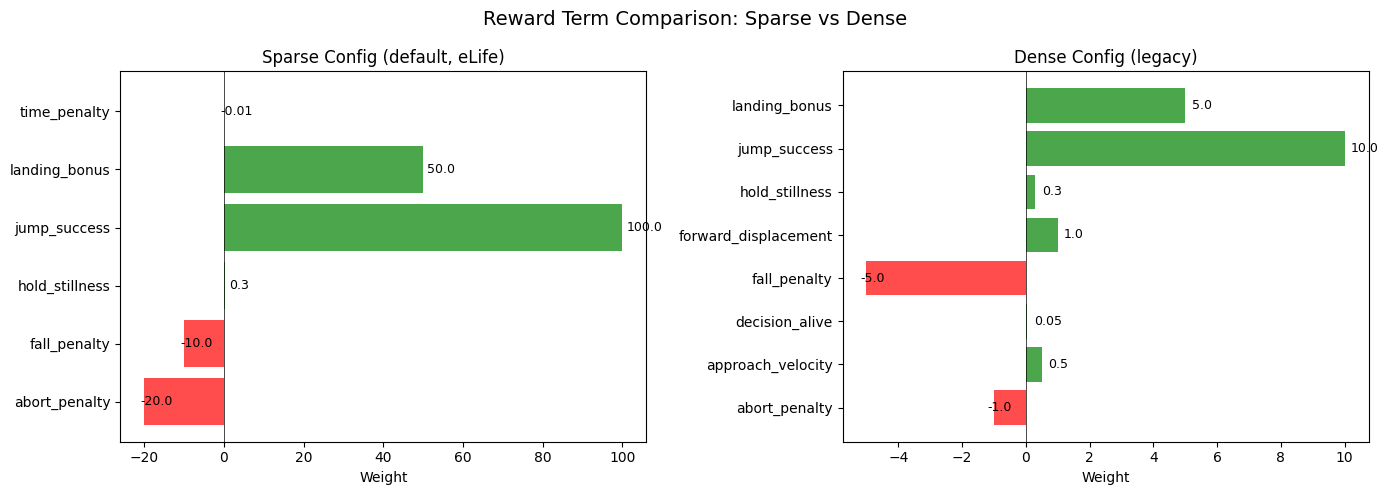


Term                          Sparse      Dense
--------------------------------------------------
abort_penalty                  -20.0       -1.0
approach_velocity                ---        0.5
decision_alive                   ---       0.05
fall_penalty                   -10.0       -5.0
forward_displacement             ---        1.0
hold_stillness                   0.3        0.3
jump_success                   100.0       10.0
landing_bonus                   50.0        5.0
time_penalty                   -0.01        ---


In [10]:
sparse_cfg = default_config()
dense_cfg = dense_config()

sparse_terms = sparse_cfg.reward_terms
dense_terms = dense_cfg.reward_terms

# Collect all reward term names
all_terms = sorted(set(list(sparse_terms.keys()) + list(dense_terms.keys())))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sparse config
ax = axes[0]
sparse_names = list(sparse_terms.keys())
sparse_weights = [sparse_terms[n]["weight"] for n in sparse_names]
colors = ["green" if w > 0 else "red" for w in sparse_weights]
ax.barh(sparse_names, sparse_weights, color=colors, alpha=0.7)
ax.set_xlabel("Weight")
ax.set_title("Sparse Config (default, eLife)")
ax.axvline(x=0, color="black", linewidth=0.5)
for i, w in enumerate(sparse_weights):
    ax.text(w + (1 if w > 0 else -1), i, f"{w}", va="center", fontsize=9)

# Dense config
ax = axes[1]
dense_names = list(dense_terms.keys())
dense_weights = [dense_terms[n]["weight"] for n in dense_names]
colors = ["green" if w > 0 else "red" for w in dense_weights]
ax.barh(dense_names, dense_weights, color=colors, alpha=0.7)
ax.set_xlabel("Weight")
ax.set_title("Dense Config (legacy)")
ax.axvline(x=0, color="black", linewidth=0.5)
for i, w in enumerate(dense_weights):
    ax.text(w + (0.2 if w > 0 else -0.2), i, f"{w}", va="center", fontsize=9)

plt.suptitle("Reward Term Comparison: Sparse vs Dense", fontsize=14)
plt.tight_layout()
plt.show()

# Print comparison table
print(f"\n{'Term':<25} {'Sparse':>10} {'Dense':>10}")
print("-" * 50)
for term in all_terms:
    s_w = sparse_terms.get(term, {}).get("weight", "---")
    d_w = dense_terms.get(term, {}).get("weight", "---")
    print(f"{term:<25} {str(s_w):>10} {str(d_w):>10}")

## 6. Curriculum Overview

Visualize the 3 curriculum phases and their gap distance distributions.

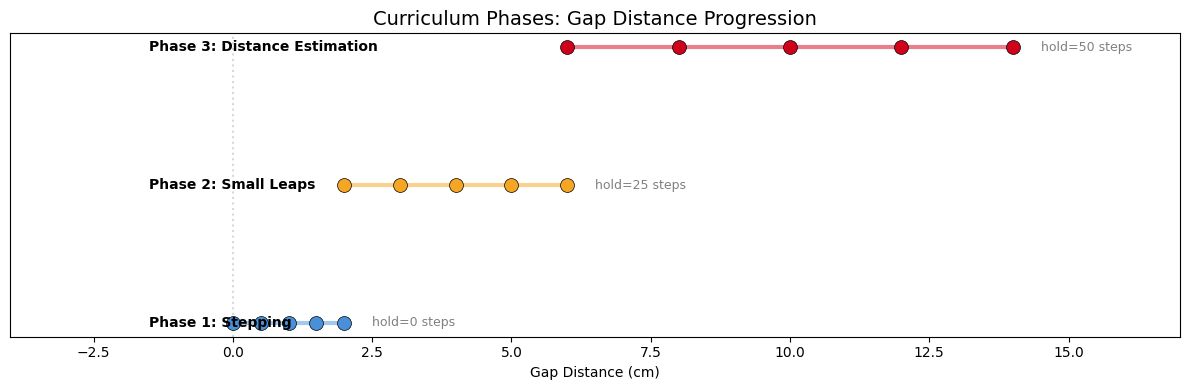

In [11]:
curriculum_phases = [
    {
        "name": "Phase 1: Stepping",
        "gaps": [0.0, 0.5, 1.0, 1.5, 2.0],
        "hold": 0,
        "color": "#4A90D9",
    },
    {
        "name": "Phase 2: Small Leaps",
        "gaps": [2, 3, 4, 5, 6],
        "hold": 25,
        "color": "#F5A623",
    },
    {
        "name": "Phase 3: Distance Estimation",
        "gaps": [6, 8, 10, 12, 14],
        "hold": 50,
        "color": "#D0021B",
    },
]

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

for i, phase in enumerate(curriculum_phases):
    gaps = phase["gaps"]
    y = [i] * len(gaps)
    ax.scatter(
        gaps, y, s=100, c=phase["color"], zorder=3, edgecolors="black", linewidth=0.5
    )
    ax.plot(
        [min(gaps), max(gaps)], [i, i], color=phase["color"], linewidth=3, alpha=0.5
    )
    ax.text(-1.5, i, phase["name"], va="center", fontsize=10, fontweight="bold")
    ax.text(
        max(gaps) + 0.5,
        i,
        f"hold={phase['hold']} steps",
        va="center",
        fontsize=9,
        color="gray",
    )

ax.set_xlabel("Gap Distance (cm)")
ax.set_yticks([])
ax.set_xlim(-4, 17)
ax.set_title("Curriculum Phases: Gap Distance Progression", fontsize=14)
ax.axvline(x=0, color="gray", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Save Videos

In [12]:
output_dir = os.path.dirname(os.path.abspath("__file__"))

if frames:
    video_path = os.path.join(output_dir, "gap_jump_trial_close_profile.mp4")
    media.write_video(video_path, frames, fps=fps // render_every)
    print(f"Saved: {video_path}")
else:
    print("No frames to save (rollout may have terminated early).")

print(f"\nOutput directory: {output_dir}")

Saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/notebooks/gaps-related/gap_jump_trial_close_profile.mp4

Output directory: /home/talmolab/Desktop/SalkResearch/vnl-playground/notebooks/gaps-related
